In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [21]:
df = pd.read_csv('numbered_mpc.csv')
df

,desgs,epoch,M,omega,Omega,inc,ecc,a,H
0,1,2023-02-25,17.21569,73.47045,80.26013,10.58635,0.078817,2.767182,3.33
1,2,2023-02-25,357.84942,310.86479,172.91814,34.92703,0.230084,2.769632,4.12
2,3,2023-02-25,351.82414,247.73655,169.84298,12.99067,0.256468,2.670137,5.16
3,4,2023-02-25,115.13301,151.59911,103.75733,7.13926,0.088758,2.363038,3.22
4,5,2023-02-25,256.02913,358.88647,141.52285,5.36013,0.187924,2.578698,7.00
...,...,...,...,...,...,...,...,...,...
620103,620104,2023-02-25,251.80563,19.74625,113.15463,48.93432,0.398342,1.502062,18.51
620104,620105,2023-02-25,147.17894,18.19102,341.13828,17.75139,0.433360,1.495524,19.49
620105,620106,2023-02-25,356.14201,19.48939,268.67767,7.95984,0.524413,1.908353,20.25
620106,620107,2023-02-25,234.73513,26.93937,197.59185,8.07880,0.559067,2.012071,19.58


## Dataframe contains the orbital elements and H mangitude (typically defined in the V band).  Most asteroids are reddish and so are dimmer in B than in V.  17th magnitude cutoff in B is probably like a 16th mag cutoff in V.  I'll go with an 17th mag cutoff, to be super safe! 


I want to know - optimistically - how close an asteroid could come to the earth. The closest approach gives an upper bound on brightness, we'll keep anything that might be observed. 


For any inclination, a simple lower bound on Earth–asteroid distance comes from heliocentric radial ranges.  
If $q=a(1-e)$ and $Q=a(1+e)$, then with Earth $q_E\approx0.983 \mathrm{AU}$, $Q_E\approx1.017\,\mathrm{AU}$,

$d_{\min} \ge \max(0,\; q_A-Q_E,\; q_E-Q_A)$

This is a valid lower bound by $\mathbf r_A-\mathbf r_E\|\ge |r_A-r_E|$; if it is positive, the asteroid cannot approach Earth more closely than that.

Text(0, 0.5, 'Count')

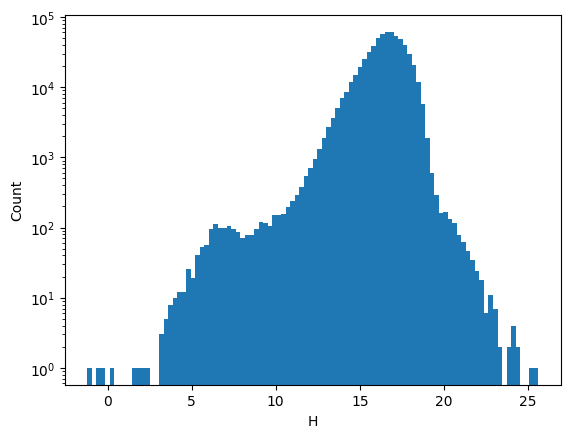

In [22]:
plt.hist(df['H'],bins=100)
plt.yscale('log')
plt.xlabel("H")
plt.ylabel("Count")

In [23]:
# Earth conservative 2001–2100 radial bounds, in AU
q_E = 0.9832436
Q_E = 1.0167543

# asteroid perihelion/aphelion distances
df["q"] = df["a"] * (1 - df["ecc"])
df["Q"] = df["a"] * (1 + df["ecc"])

# radial lower bound on Earth-asteroid distance, in AU (if zero, we have no bound! but that's okay, we just keep those cases)
df["min_dist_bound_AU"] = np.max([np.zeros(len(df)), df["q"] - Q_E, q_E - df["Q"]], axis=0)

#now we can get a maximum brightness in H, given this bound. We assume the asteroid is BOTH at perihelion and the distance is minimized (very optimistic)
df["V_bright_bound"] = df["H"] + 5 * np.log10(df["q"] * df["min_dist_bound_AU"]) #warnings may be reased when min_dist = 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Limiting Mag is ~17 (optimistically)
https://hea-www.harvard.edu/DASCH/papers/coverage6041/aavso5.pdf

We have about 10^4 asteroids to check.

In [24]:
subdf = df[df["V_bright_bound"] < 17.0]
subdf

,desgs,epoch,M,omega,Omega,inc,ecc,a,H,q,Q,min_dist_bound_AU,V_bright_bound
0,1,2023-02-25,17.21569,73.47045,80.26013,10.58635,0.078817,2.767182,3.33,2.549079,2.985284,1.532325,6.288671
1,2,2023-02-25,357.84942,310.86479,172.91814,34.92703,0.230084,2.769632,4.12,2.132383,3.406881,1.115628,6.001923
2,3,2023-02-25,351.82414,247.73655,169.84298,12.99067,0.256468,2.670137,5.16,1.985333,3.354941,0.968579,6.579841
3,4,2023-02-25,115.13301,151.59911,103.75733,7.13926,0.088758,2.363038,3.22,2.153301,2.572776,1.136547,5.163460
4,5,2023-02-25,256.02913,358.88647,141.52285,5.36013,0.187924,2.578698,7.00,2.094099,3.063296,1.077345,8.766761
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620103,620104,2023-02-25,251.80563,19.74625,113.15463,48.93432,0.398342,1.502062,18.51,0.903727,2.100397,0.000000,-inf
620104,620105,2023-02-25,147.17894,18.19102,341.13828,17.75139,0.433360,1.495524,19.49,0.847424,2.143624,0.000000,-inf
620105,620106,2023-02-25,356.14201,19.48939,268.67767,7.95984,0.524413,1.908353,20.25,0.907588,2.909118,0.000000,-inf
620106,620107,2023-02-25,234.73513,26.93937,197.59185,8.07880,0.559067,2.012071,19.58,0.887189,3.136953,0.000000,-inf


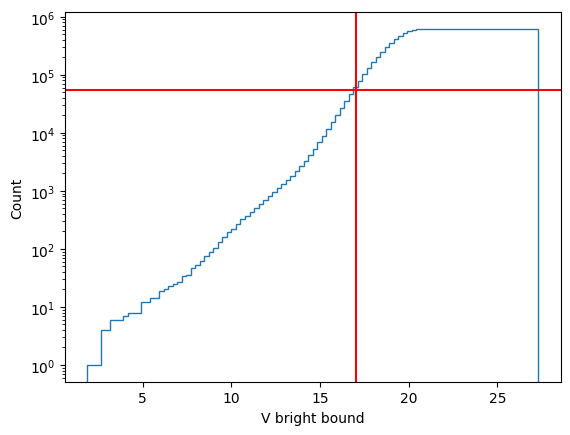

In [25]:
x = df["V_bright_bound"].to_numpy()
x = x[np.isfinite(x)]

plt.hist(x, bins=100, cumulative=True, histtype="step")
plt.yscale("log")
plt.xlabel("V bright bound")
plt.ylabel("Count")
plt.axvline(17, c="r")
plt.axhline(len(subdf), c="r")
plt.savefig("rough_filtering.png")

## We'll keep all suriving objects!

In [26]:
subdf.to_csv("targets.csv",index=False)

# Plotting the asteroids after the filter has been applied

In [27]:
def filter_by_mass(df, H_max, albedo, density): 
    """Asked AI for the parameters"""
    """
    Filter asteroids by mass.
    
    H → diameter via standard formula, then volume * density.
    
    Parameters:
        H_max   : upper H magnitude limit (higher H = smaller/lighter)
        albedo  : geometric albedo (default 0.15) #Needed the parameter of albedo
        density : kg/m³ (default 1500)
    """

    D_km = (1329 / np.sqrt(albedo)) * 10 ** (-H_max / 5)   # Formula fven by AI
    D_m  = D_km * 1000
    mass_min_kg = density * (4/3) * np.pi * (D_m / 2) ** 3  # sphere approximation

    df["diameter_km"]  = (1329 / np.sqrt(albedo)) * 10 ** (-df["H"] / 5)
    df["mass_kg"]      = density * (4/3) * np.pi * ((df["diameter_km"] * 1000) / 2) ** 3

    return df[df["mass_kg"] >= mass_min_kg]

In [28]:
def filter_by_distance(df, max_min_dist_AU):
    """
    Filter asteroids by their minimum possible Earth-approach distance.
    
    Keeps asteroids that can get within max_min_dist_AU of Earth's orbit.

    Parameters:
        max_min_dist_AU : distance threshold in AU (default 0.3 — roughly Mars-crossing)
    """
    if "min_dist_bound_AU" not in df.columns:
        df["q"] = df["a"] * (1 - df["ecc"])
        df["Q"] = df["a"] * (1 + df["ecc"])
        df["min_dist_bound_AU"] = np.max(
            [np.zeros(len(df)), df["q"] - Q_E, q_E - df["Q"]], axis=0
        )

    return df[df["min_dist_bound_AU"] <= max_min_dist_AU]

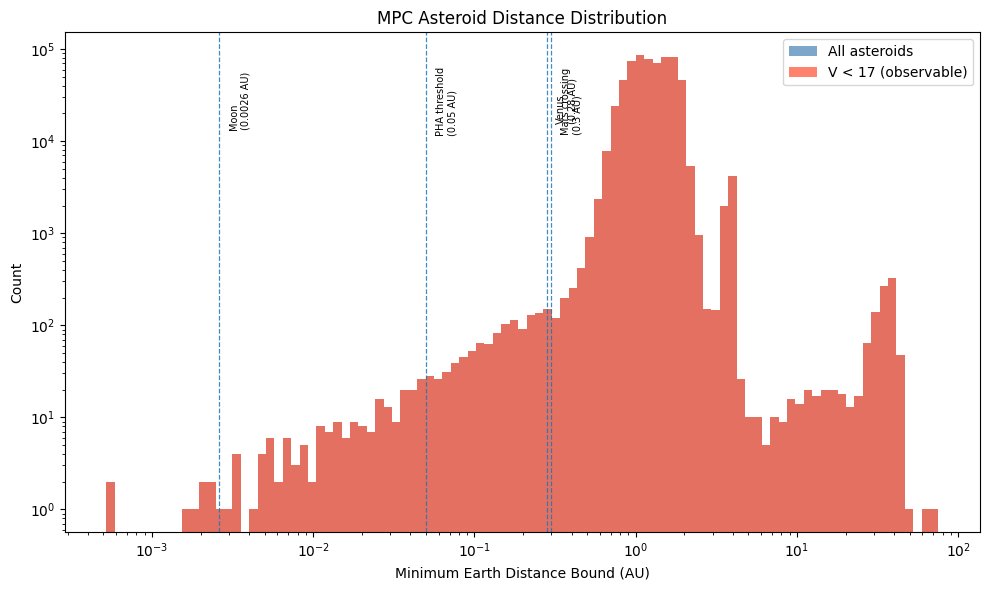

In [29]:
subdf = filter_by_distance(df, 5000)

fig, ax = plt.subplots(figsize=(10, 6))

# drop zeros and non-finite — can't log a zero
dist_all = df["min_dist_bound_AU"].replace(0, np.nan).dropna()
dist_obs = subdf["min_dist_bound_AU"].replace(0, np.nan).dropna()

bins = np.logspace(
    np.log10(dist_all.min()),
    np.log10(dist_all.max()),
    100
)

ax.hist(dist_all, bins=bins, color="steelblue", alpha=0.7, label="All asteroids")
ax.hist(dist_obs, bins=bins, color="tomato",    alpha=0.8, label="V < 17 (observable)")

# reference distances
references = {
    "Moon\n(0.0026 AU)":         0.0026,
    "PHA threshold\n(0.05 AU)":  0.05,
    "Venus\n(0.28 AU)":          0.28,
    "Mars crossing\n(0.3 AU)":   0.3,
}

for label, dist in references.items():
    ax.axvline(dist, linestyle="--", linewidth=0.9, alpha=0.85)
    ax.text(dist * 1.15, ax.get_ylim()[1] * 0.3, label,
            fontsize=7, rotation=90, va="center")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Minimum Earth Distance Bound (AU)")
ax.set_ylabel("Count")
ax.set_title("MPC Asteroid Distance Distribution")
ax.legend()

plt.tight_layout()
plt.savefig("distance_histogram.png", dpi=150)
plt.show()

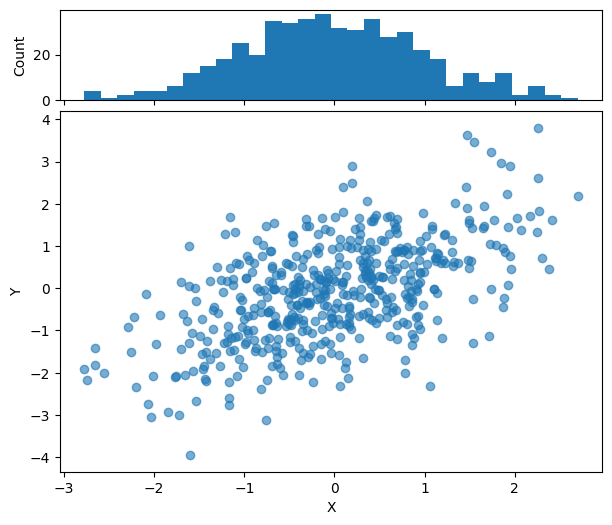

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
np.random.seed(0)
x = np.random.normal(size=500)
y = 0.7 * x + np.random.normal(size=500)

# Create layout: histogram on top, scatter below
fig, (ax_hist, ax_scatter) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,gridspec_kw={"height_ratios": [1, 4], "hspace": 0.05})

# Top histogram
ax_hist.hist(x, bins=30)
ax_hist.set_ylabel("Count")
ax_hist.tick_params(axis="x", labelbottom=False)

# Scatterplot
ax_scatter.scatter(x, y, alpha=0.6)
ax_scatter.set_xlabel("X")
ax_scatter.set_ylabel("Y")

plt.show()